In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/intent_binary_best.pt
/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/restorer_best.pt
/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/quality_judge_best.pt
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0032.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0026.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0040.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0056.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0009.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0011.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0018.npy
/kaggle/input/datasets/jorgeoc/prepare

In [2]:
# =========================
# CELDA 1: Imports
# =========================
import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn


In [3]:
# =========================
# CELDA 2: Arquitecturas
# =========================
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, dilation=1, drop=0.1):
        super().__init__()
        pad = (k - 1) * dilation // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(drop)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        s = self.skip(x)
        x = self.drop(self.act(self.bn1(self.conv1(x))))
        x = self.drop(self.act(self.bn2(self.conv2(x))))
        return self.act(x + s)

class IntentTCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
        )
        self.tcn = nn.Sequential(
            TCNBlock(16, 16, dilation=1, drop=0.10),
            TCNBlock(16, 32, dilation=2, drop=0.10),
            TCNBlock(32, 32, dilation=4, drop=0.10),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.tcn(x)
        x = self.pool(x)
        return self.head(x)

class QualityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        self.head_score = nn.Linear(32, 1)
        self.head_label = nn.Linear(32, 1)

    def forward(self, x):
        z = self.features(x)
        z = self.shared(z)
        q_score = torch.sigmoid(self.head_score(z))
        q_logit = self.head_label(z)
        return q_score, q_logit

class ConvAE1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 5, stride=2, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, 5, stride=2, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, 5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.bottleneck = nn.Sequential(
            nn.Conv1d(64, 64, 3, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.ConvTranspose1d(16, 1, 4, stride=2, padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        z = self.bottleneck(z)
        y = self.decoder(z)
        return y


In [4]:
# =========================
# CELDA 3: Cargar modelos
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

candidate_model_dirs = []

for p in glob.glob("/kaggle/input/**/intent_binary_best.pt", recursive=True):
    model_dir = os.path.dirname(p)
    q_path = os.path.join(model_dir, "quality_judge_best.pt")
    r_path = os.path.join(model_dir, "restorer_best.pt")

    if os.path.exists(q_path) and os.path.exists(r_path):
        candidate_model_dirs.append(model_dir)

print("Candidatos de modelos encontrados:")
for c in candidate_model_dirs:
    print(" -", c)

if not candidate_model_dirs:
    raise FileNotFoundError(
        "No encontré un directorio de modelos válido con "
        "intent_binary_best.pt, quality_judge_best.pt y restorer_best.pt"
    )

MODELS_DIR = candidate_model_dirs[0]
print("\nUsando MODELS_DIR:", MODELS_DIR)

intent_model = IntentTCN().to(device)
intent_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "intent_binary_best.pt"), map_location=device))
intent_model.eval()

quality_model = QualityNet().to(device)
quality_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "quality_judge_best.pt"), map_location=device))
quality_model.eval()

restorer_model = ConvAE1D().to(device)
restorer_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "restorer_best.pt"), map_location=device))
restorer_model.eval()

print("Modelos cargados correctamente.")


device: cuda
Candidatos de modelos encontrados:
 - /kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1

Usando MODELS_DIR: /kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1
Modelos cargados correctamente.


In [5]:
# =========================
# CELDA 4: Utilidades
# =========================
THR_INTENT = 0.50
THR_QUALITY = 0.50
WIN = 400
STRIDE = 200

def robust_norm_1d(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-6
    z = (x - med) / (1.4826 * mad)
    return np.clip(z, -10, 10).astype(np.float32)

def windows_1d(sig, win=400, stride=200):
    idxs = np.arange(0, len(sig) - win + 1, stride)
    return np.stack([sig[i:i+win] for i in idxs], axis=0)[:, None, :].astype(np.float32)

def mae_np(a, b):
    return float(np.mean(np.abs(a - b)))

def snr_db(clean, noisy):
    noise = noisy - clean
    ps = np.mean(clean**2) + 1e-8
    pn = np.mean(noise**2) + 1e-8
    return float(10 * np.log10(ps / pn))

@torch.no_grad()
def infer_one_window(x_window, thr_intent=0.50, thr_quality=0.50):
    """
    x_window: np.array (1, 400) o (1,1,400)
    """
    if x_window.ndim == 2:
        x_window = x_window[None, :, :]
    xb = torch.tensor(x_window, dtype=torch.float32, device=device)

    t0 = time.perf_counter()

    intent_logits = intent_model(xb)
    p_intent = float(torch.sigmoid(intent_logits).cpu().numpy().reshape(-1)[0])

    q_score_pred, q_logit = quality_model(xb)
    q_score_pred = float(q_score_pred.cpu().numpy().reshape(-1)[0])
    q_prob_good = float(torch.sigmoid(q_logit).cpu().numpy().reshape(-1)[0])

    if p_intent < thr_intent:
        decision = "skip_restore"
        reason = "no_intent_detected"
        out = x_window[0].copy()
    elif q_prob_good >= thr_quality:
        decision = "skip_restore"
        reason = "signal_quality_good_enough"
        out = x_window[0].copy()
    else:
        decision = "restore"
        reason = "intent_detected_and_quality_bad"
        out = restorer_model(xb).cpu().numpy()[0]

    t1 = time.perf_counter()
    latency_ms = (t1 - t0) * 1000.0

    return {
        "p_intent": p_intent,
        "q_score_pred": q_score_pred,
        "q_prob_good": q_prob_good,
        "decision": decision,
        "reason": reason,
        "latency_ms": latency_ms,
        "output_window": out.astype(np.float32),
    }

def infer_batch(x_batch, thr_intent=0.50, thr_quality=0.50):
    rows = []
    x_out = []
    latencies = []

    for i in range(len(x_batch)):
        res = infer_one_window(x_batch[i], thr_intent=thr_intent, thr_quality=thr_quality)
        rows.append({
            "idx": i,
            "p_intent": res["p_intent"],
            "q_score_pred": res["q_score_pred"],
            "q_prob_good": res["q_prob_good"],
            "decision": res["decision"],
            "reason": res["reason"],
            "latency_ms": res["latency_ms"],
        })
        x_out.append(res["output_window"])
        latencies.append(res["latency_ms"])

    return pd.DataFrame(rows), np.stack(x_out).astype(np.float32), np.array(latencies, dtype=np.float32)


In [6]:
# =========================
# CELDA 5: Elegir fuente
# =========================
SOURCE_MODE = "dataset"
# opciones:
# "dataset"
# "synthetic"
# "external_file"

external_path = None
# ejemplo:
# external_path = "/kaggle/input/mi-senal/senal.npy"
# external_path = "/kaggle/input/mi-senal/senal.csv"
# external_path = "/kaggle/input/mi-senal/senal.txt"


In [7]:
# =========================
# CELDA 6: Dataset real
# =========================
x_in = None
x_clean_ref = None

if SOURCE_MODE == "dataset":
    candidate_dirs = []
    for p in glob.glob("/kaggle/input/**/restoration_dataset", recursive=True):
        if os.path.isdir(p):
            xcorr = glob.glob(os.path.join(p, "Xcorr_*.npy"))
            xclean = glob.glob(os.path.join(p, "Xclean_*.npy"))
            if len(xcorr) > 0 and len(xclean) > 0:
                candidate_dirs.append(p)

    if not candidate_dirs:
        raise FileNotFoundError("No encontré restoration_dataset.")

    RDIR = candidate_dirs[0]
    Xcorr_files = sorted(glob.glob(os.path.join(RDIR, "Xcorr_*.npy")))
    Xclean_files = sorted(glob.glob(os.path.join(RDIR, "Xclean_*.npy")))

    x_in = np.load(Xcorr_files[0])[:500]
    x_clean_ref = np.load(Xclean_files[0])[:500]

    print("Usando dataset real")
    print("x_in:", x_in.shape)
    print("x_clean_ref:", x_clean_ref.shape)


Usando dataset real
x_in: (500, 1, 400)
x_clean_ref: (500, 1, 400)


In [8]:
# =========================
# CELDA 7: Señales sintéticas
# =========================
def make_synthetic_sequence(num_windows=40, T=400, seed=123):
    rng = np.random.default_rng(seed)
    x_clean_list = []
    x_corr_list = []

    for i in range(num_windows):
        t = np.linspace(0, 1, T)

        if i % 4 == 0:
            clean = np.zeros(T, dtype=np.float32)
            clean += 0.02 * rng.normal(size=T).astype(np.float32)
        else:
            env = np.exp(-0.5 * ((t - 0.5) / 0.12)**2)
            carrier = np.sin(2*np.pi*35*t) + 0.5*np.sin(2*np.pi*70*t)
            clean = (1.8 * env * carrier).astype(np.float32)

        noisy = clean.copy()
        noisy += rng.normal(0, 0.25, size=T).astype(np.float32)

        if i % 3 == 0:
            noisy += (0.5 * np.sin(2*np.pi*1.2*t)).astype(np.float32)

        if i % 5 == 0:
            start = 120
            noisy[start:start+50] = 0.0

        x_clean_list.append(clean[None, :])
        x_corr_list.append(noisy[None, :])

    x_clean = np.stack(x_clean_list).astype(np.float32)
    x_corr = np.stack(x_corr_list).astype(np.float32)
    return x_clean, x_corr

if SOURCE_MODE == "synthetic":
    x_clean_ref, x_in = make_synthetic_sequence(num_windows=40)
    print("Usando señal sintética")
    print("x_in:", x_in.shape)
    print("x_clean_ref:", x_clean_ref.shape)


In [9]:
# =========================
# CELDA 8: Archivo externo
# =========================
def load_external_signal(path):
    if path is None:
        raise ValueError("Asigna external_path.")
    if path.endswith(".npy"):
        sig = np.load(path).astype(np.float32).reshape(-1)
    elif path.endswith(".csv"):
        sig = np.loadtxt(path, delimiter=",", dtype=np.float32).reshape(-1)
    elif path.endswith(".txt"):
        sig = np.loadtxt(path, dtype=np.float32).reshape(-1)
    else:
        raise ValueError("Formato no soportado. Usa .npy, .csv o .txt")
    return robust_norm_1d(sig)

if SOURCE_MODE == "external_file":
    sig_ext = load_external_signal(external_path)
    x_in = windows_1d(sig_ext, win=WIN, stride=STRIDE)
    x_clean_ref = None

    print("Usando archivo externo")
    print("x_in:", x_in.shape)


In [10]:
# =========================
# CELDA 9: Inferencia
# =========================
if x_in is None:
    raise ValueError("No se cargó ninguna fuente de entrada. Revisa SOURCE_MODE.")

df_inf, x_out, lat_ms = infer_batch(
    x_in,
    thr_intent=THR_INTENT,
    thr_quality=THR_QUALITY
)

print(df_inf.head())
print()
print("Latencia promedio (ms):", float(lat_ms.mean()))
print("Latencia mediana (ms):", float(np.median(lat_ms)))
print("Latencia min/max (ms):", float(lat_ms.min()), float(lat_ms.max()))


   idx  p_intent  q_score_pred  q_prob_good      decision  \
0    0  0.885436      0.365641     0.000270       restore   
1    1  0.278118      0.950326     0.996506  skip_restore   
2    2  0.940655      0.999781     0.999999  skip_restore   
3    3  0.620910      0.423496     0.004911       restore   
4    4  0.924138      0.999703     1.000000  skip_restore   

                            reason   latency_ms  
0  intent_detected_and_quality_bad  1082.101949  
1               no_intent_detected     3.603328  
2       signal_quality_good_enough     2.463255  
3  intent_detected_and_quality_bad     3.234171  
4       signal_quality_good_enough     2.257941  

Latencia promedio (ms): 4.618828296661377
Latencia mediana (ms): 2.1922388076782227
Latencia min/max (ms): 2.110044002532959 1082.1019287109375


In [11]:
# =========================
# CELDA 10: Resumen
# =========================
print("Conteo de decisiones:")
print(df_inf["decision"].value_counts(dropna=False))
print()

print("Razones:")
print(df_inf["reason"].value_counts(dropna=False))
print()

print("Latencia por decisión:")
print(df_inf.groupby("decision")["latency_ms"].describe())


Conteo de decisiones:
decision
skip_restore    385
restore         115
Name: count, dtype: int64

Razones:
reason
signal_quality_good_enough         272
intent_detected_and_quality_bad    115
no_intent_detected                 113
Name: count, dtype: int64

Latencia por decisión:
              count       mean         std       min       25%      50%  \
decision                                                                  
restore       115.0  12.445696  100.621240  2.869709  2.939985  2.96641   
skip_restore  385.0   2.280933    0.307497  2.110044  2.145999  2.17040   

                   75%          max  
decision                             
restore       3.033797  1082.101949  
skip_restore  2.230937     4.054242  


In [12]:
# =========================
# CELDA 11: Métricas con referencia
# =========================
if x_clean_ref is not None:
    records = []
    for i in range(len(x_in)):
        clean = x_clean_ref[i, 0]
        corr = x_in[i, 0]
        out = x_out[i, 0]

        records.append({
            "idx": i,
            "decision": df_inf.iloc[i]["decision"],
            "reason": df_inf.iloc[i]["reason"],
            "mae_before": mae_np(clean, corr),
            "mae_after": mae_np(clean, out),
            "snr_before": snr_db(clean, corr),
            "snr_after": snr_db(clean, out),
            "improved_mae": mae_np(clean, out) < mae_np(clean, corr),
            "improved_snr": snr_db(clean, out) > snr_db(clean, corr),
        })

    df_metrics = pd.DataFrame(records)

    print("Promedios globales:")
    print(df_metrics[["mae_before", "mae_after", "snr_before", "snr_after"]].mean())
    print()

    dfr = df_metrics[df_metrics["decision"] == "restore"]
    if len(dfr):
        print("Solo restauradas:")
        print(dfr[["mae_before", "mae_after", "snr_before", "snr_after"]].mean())
        print("Frac mejora MAE:", dfr["improved_mae"].mean())
        print("Frac mejora SNR:", dfr["improved_snr"].mean())
else:
    print("No hay señal limpia de referencia; se omiten métricas antes/después.")


Promedios globales:
mae_before     0.944906
mae_after      0.481592
snr_before    25.050420
snr_after     27.806841
dtype: float64

Solo restauradas:
mae_before     2.551105
mae_after      0.536694
snr_before     6.086092
snr_after     18.070531
dtype: float64
Frac mejora MAE: 0.9739130434782609
Frac mejora SNR: 0.9826086956521739


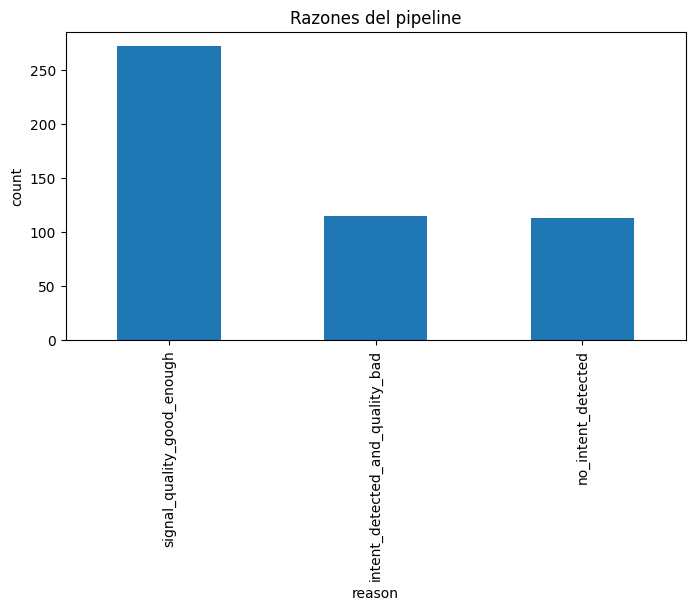

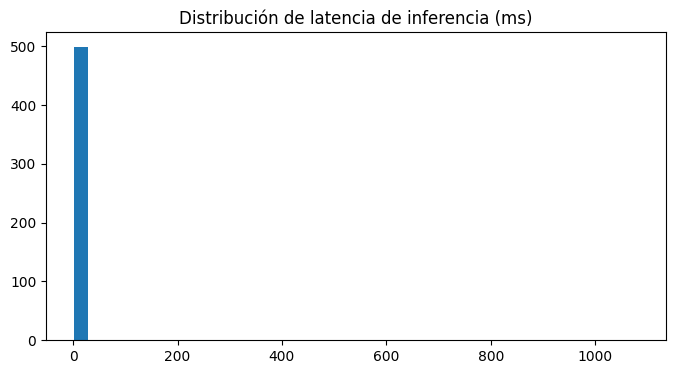

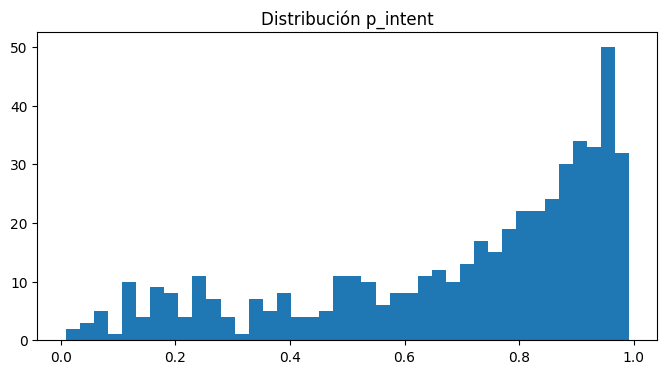

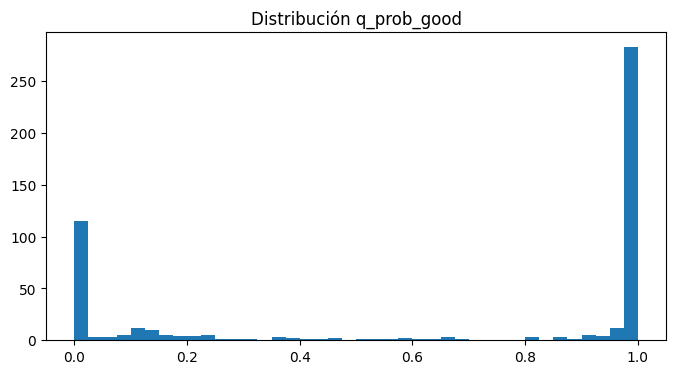

In [13]:
# =========================
# CELDA 12: Gráficas
# =========================
plt.figure(figsize=(8,4))
df_inf["reason"].value_counts().plot(kind="bar")
plt.title("Razones del pipeline")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df_inf["latency_ms"], bins=40)
plt.title("Distribución de latencia de inferencia (ms)")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df_inf["p_intent"], bins=40)
plt.title("Distribución p_intent")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df_inf["q_prob_good"], bins=40)
plt.title("Distribución q_prob_good")
plt.show()


idx=0
decision=restore | reason=intent_detected_and_quality_bad
p_intent=0.885 | q_score_pred=0.366 | q_prob_good=0.000
latency_ms=1082.102



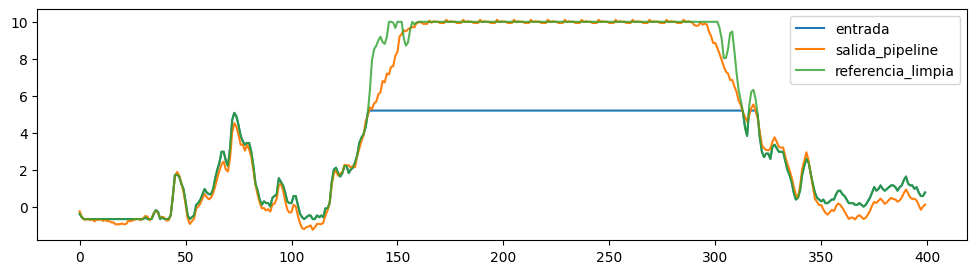

idx=1
decision=skip_restore | reason=no_intent_detected
p_intent=0.278 | q_score_pred=0.950 | q_prob_good=0.997
latency_ms=3.603



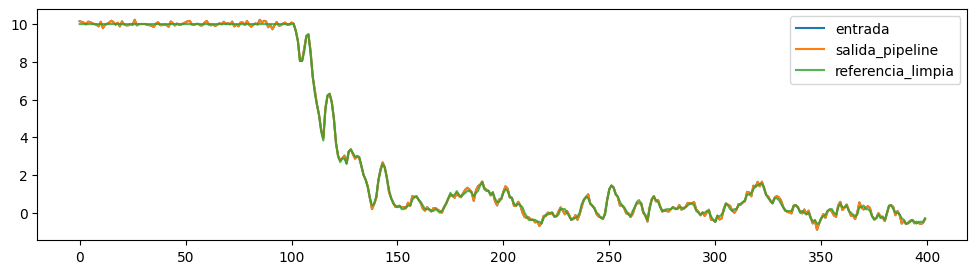

idx=2
decision=skip_restore | reason=signal_quality_good_enough
p_intent=0.941 | q_score_pred=1.000 | q_prob_good=1.000
latency_ms=2.463



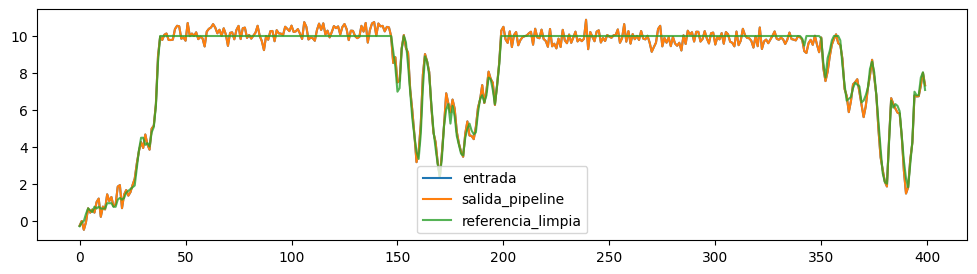

idx=3
decision=restore | reason=intent_detected_and_quality_bad
p_intent=0.621 | q_score_pred=0.423 | q_prob_good=0.005
latency_ms=3.234



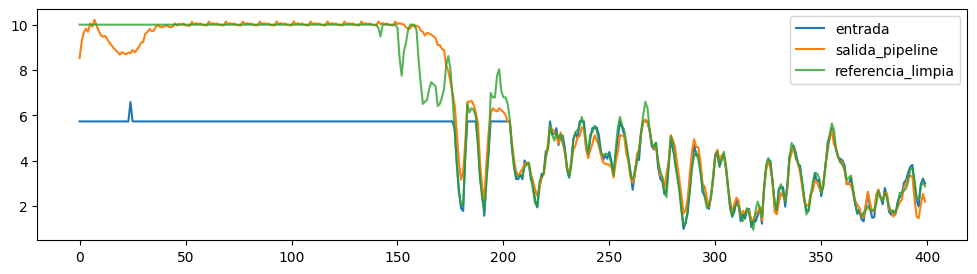

idx=4
decision=skip_restore | reason=signal_quality_good_enough
p_intent=0.924 | q_score_pred=1.000 | q_prob_good=1.000
latency_ms=2.258



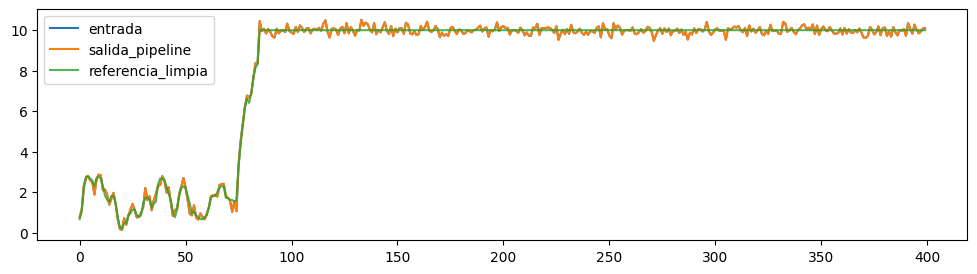

idx=5
decision=skip_restore | reason=signal_quality_good_enough
p_intent=0.965 | q_score_pred=1.000 | q_prob_good=1.000
latency_ms=2.171



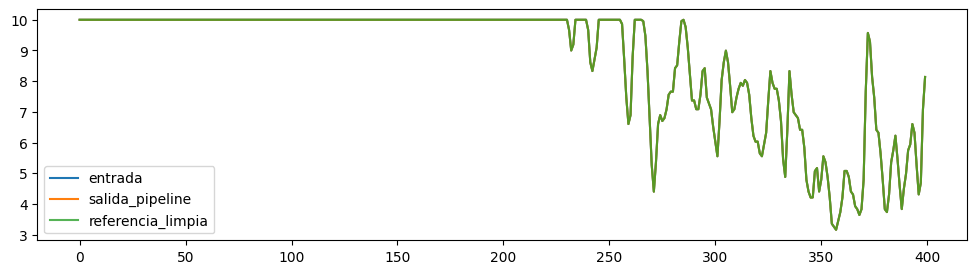

In [14]:
# =========================
# CELDA 13: Ejemplos
# =========================
num_examples = min(6, len(x_in))

for i in range(num_examples):
    row = df_inf.iloc[i]
    print(f"idx={i}")
    print(f"decision={row['decision']} | reason={row['reason']}")
    print(f"p_intent={row['p_intent']:.3f} | q_score_pred={row['q_score_pred']:.3f} | q_prob_good={row['q_prob_good']:.3f}")
    print(f"latency_ms={row['latency_ms']:.3f}")
    print()

    plt.figure(figsize=(12,3))
    plt.plot(x_in[i,0], label="entrada")
    plt.plot(x_out[i,0], label="salida_pipeline")
    if x_clean_ref is not None:
        plt.plot(x_clean_ref[i,0], label="referencia_limpia", alpha=0.8)
    plt.legend()
    plt.show()


In [15]:
# =========================
# CELDA 14: Envío serial opcional
# =========================
USE_SERIAL = False
SERIAL_PORT = "COM3"   # cambia esto en Windows
SERIAL_BAUD = 115200

if USE_SERIAL:
    import serial
    import time as pytime

    ser = serial.Serial(SERIAL_PORT, SERIAL_BAUD, timeout=1)
    pytime.sleep(2)

    def map_decision_to_msg(row):
        if row["decision"] == "restore":
            return "RESTORE"
        elif row["reason"] == "signal_quality_good_enough":
            return "OK"
        else:
            return "REJECT"

    for i in range(len(df_inf)):
        msg = map_decision_to_msg(df_inf.iloc[i])
        ser.write((msg + "\n").encode("utf-8"))
        print("Enviado:", msg)
        pytime.sleep(0.2)

    ser.close()
else:
    print("USE_SERIAL=False, no se envía nada al Arduino.")


USE_SERIAL=False, no se envía nada al Arduino.
